# Linear Regression (Simple Linear Regression)

In [1]:
import numpy as np

class LinearRegressionClass:
    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        num = 0
        den = 0

        # Loop through each data point
        for i in range(X_train.shape[0]):
            num += (X_train[i] - X_train.mean()) * (y_train[i] - y_train.mean())
            den += (X_train[i] - X_train.mean()) ** 2

        # Slope (m) and Intercept (b)
        self.m = num / den
        self.b = y_train.mean() - (self.m * X_train.mean())

        print("Slope (m):", self.m)
        print("Intercept (b):", self.b)

    def predict(self, X_test):
       return self.m * X_test + self.b

Slope (m): 10.114368627620584
Intercept (b): -30.45149800343502
     CGPA  Actual Package  Predicted Package
112  8.42       54.320460          54.711486
29   7.01       39.516613          40.450226
182  9.25       60.358215          63.106412
199  8.42       51.914059          54.711486
193  8.39       51.408522          54.408055


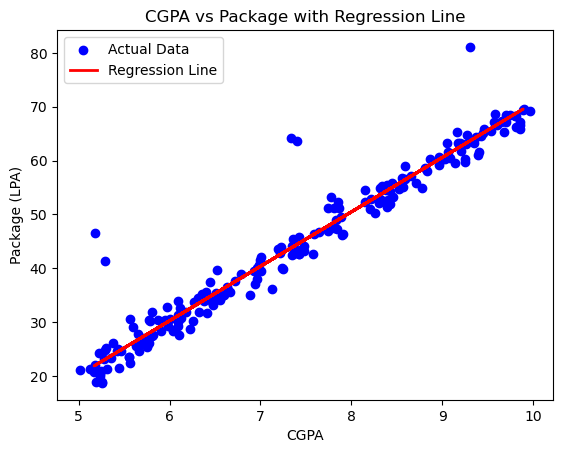

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("updated_placement.csv")

X = df[["cgpa"]]   # Feature
y = df["package"]  # Target

# Split into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Print slope and intercept
print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

# Predict on test set
y_pred = model.predict(X_test)

# Show first few predictions vs actual
results = pd.DataFrame({"CGPA": X_test["cgpa"], "Actual Package": y_test, "Predicted Package": y_pred})
print(results.head())

# Scatter plot of actual data
plt.scatter(X, y, color="blue", label="Actual Data")

# Regression line
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Regression Line")

# Labels and legend
plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")
plt.title("CGPA vs Package with Regression Line")
plt.legend()
plt.show()

# Linear Regression (Multiple Linear Regression)

In [3]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})
df.shape
df.head()

,feature1,feature2,target
0,1.365931,0.824862,13.218458
1,-1.749284,0.402238,-167.605798
2,0.324702,0.681899,26.412938
3,-0.053239,0.214032,-48.332471
4,-0.458947,0.406342,53.351013


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

lr = LinearRegression()
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 45.16613437455015
MSE 2927.549577978883
R2 score -0.08848299306976548


In [5]:
lr.coef_

array([68.58098653, -4.99944299])

In [6]:
lr.intercept_

np.float64(3.901055206964149)

# Multiple Linear Regression Example Using Advertising Data

In [7]:
from sklearn.linear_model import LinearRegression
import pandas as pd

df = pd.read_csv("Advertising.csv")
df.drop(columns = ["Unnamed: 0"], inplace=True)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [8]:
df.shape

(200, 4)

In [9]:
input_feature = ["TV", "Radio"]

X = df[input_feature]
y = df["Sales"]

In [10]:
X

,TV,Radio
0,230.1,37.8
1,44.5,39.3
2,17.2,45.9
3,151.5,41.3
4,180.8,10.8
...,...,...
195,38.2,3.7
196,94.2,4.9
197,177.0,9.3
198,283.6,42.0


In [11]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64

In [12]:
model = LinearRegression()
model.fit(X,y)

print("b0 Intercept :" , model.intercept_)
print("Slope b1 & b2 :" , model.coef_)

b0 Intercept : 2.9210999124051362
Slope b1 & b2 : [0.04575482 0.18799423]


In [13]:
y_pred = model.predict(X)
print(y_pred)

[20.55546463 12.34536229 12.33701773 17.61711596 13.22390813 12.51208449
 11.71821241 12.10551553  3.7093792  12.55169696  7.0358597  17.25652015
 10.60866187  8.81095051 18.44466773 20.82891539 12.90386507 23.24107626
  9.94121476 14.15384619 18.12139161 14.74206357  6.51417168 16.54402663
  8.14035215 15.6080206  14.96769383 17.0463346  19.39954145  9.15929748
 21.64292187 11.35791808  7.65045928 18.83346334  7.56302763 16.99280099
 23.36720719 15.6258994   9.91257829 20.4405801  16.37872122 17.29870935
 21.5621537  13.96692266  8.9009974  15.16263814  8.88644967 21.69944046
 16.28690268  8.18162949 12.64569407  9.31962792 20.66180115 19.96126242
 20.35512357 21.30864743  8.53774783 12.76239488 21.89072858 18.10746914
  5.74497097 22.90418658 16.78413768 13.18474853 16.96570907  7.82652846
  8.98703456 12.02066194 18.95313425 21.09369037 17.78350693 10.63329605
 10.35113844  9.91334008 17.30983543 11.90970399  4.48014809 13.79239059
  8.78920329  9.67621401 11.43621364 14.6638809  10

In [14]:
r2 = model.score(X,y)
print(r2)

0.8971942610828956


In [15]:
new = [[200, 300]]
print(model.predict(new))

[68.47033092]


C:\Users\tanma\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
